In [5]:
# Step 1 — Import Libraries

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from PIL import Image

from sklearn.metrics import confusion_matrix
import seaborn as sns

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cpu
CUDA available: False


In [6]:
# Step 2 — Device Configuration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [7]:
# Step 3 — Clone GitHub Repository

!git clone https://github.com/mdparvezcse/CNN_Image_Classification.git

Cloning into 'CNN_Image_Classification'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 40 (delta 3), reused 40 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 32.08 MiB | 29.22 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [8]:
# Check repository files

!ls

CNN_Image_Classification  sample_data


In [9]:
# Step 4 — Check Custom Images

REPO_PATH = "/content/FashionMNIST-CNN"
CUSTOM_PATH = os.path.join(REPO_PATH, "dataset")

print("Custom dataset path:", CUSTOM_PATH)

!find /content/FashionMNIST-CNN/dataset -maxdepth 1 -type f

Custom dataset path: /content/FashionMNIST-CNN/dataset
find: ‘/content/FashionMNIST-CNN/dataset’: No such file or directory


In [10]:
# Check folders inside /content

!ls -la /content

total 20
drwxr-xr-x 1 root root 4096 Aug 16 21:19 .
drwxr-xr-x 1 root root 4096 Aug 16 21:15 ..
drwxr-xr-x 4 root root 4096 Aug 16 21:19 CNN_Image_Classification
drwxr-xr-x 4 root root 4096 Aug 10 13:26 .config
drwxr-xr-x 1 root root 4096 Aug 10 13:26 sample_data


In [11]:
!find /content/FashionMNIST-CNN -maxdepth 3 -type f

find: ‘/content/FashionMNIST-CNN’: No such file or directory


In [12]:
# Step 5 — FashionMNIST Classes

classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print(classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [13]:
# Step 6 — Image Transformation

transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [14]:
# Step 7 — Download FashionMNIST Dataset

train_dataset_full = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Full training dataset:", len(train_dataset_full))
print("Test dataset:", len(test_dataset))

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.9MB/s]

Full training dataset: 60000
Test dataset: 10000


In [15]:
# Step 8 — Train / Validation Split

train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size]
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 48000
Validation samples: 12000


In [16]:
# Step 9 — DataLoaders

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


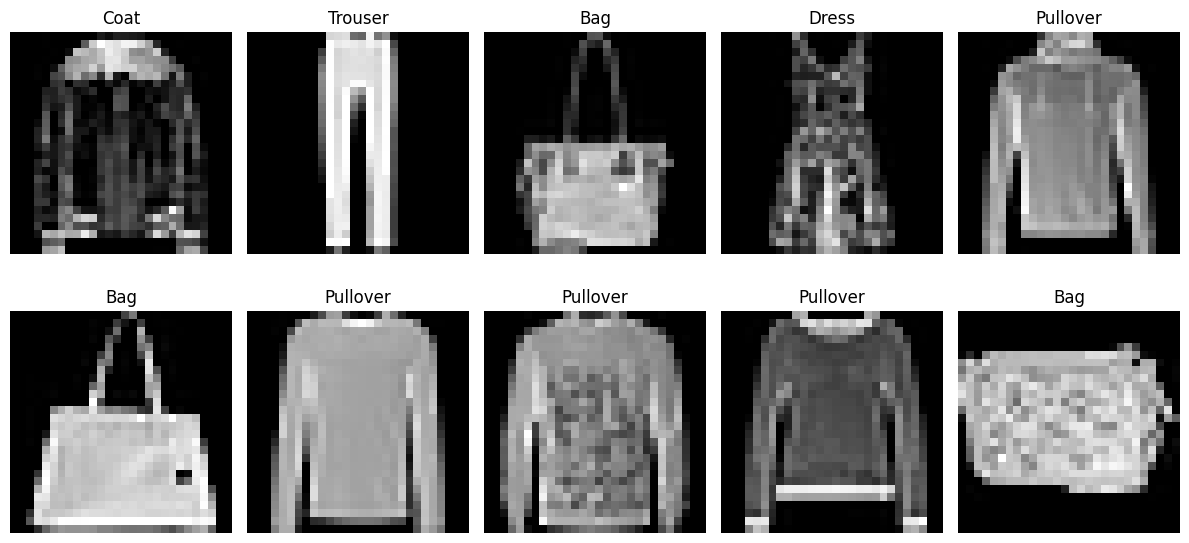

In [17]:
# Step 10 — Display Sample Images

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    image = images[i].squeeze().numpy()

    # Undo normalization
    image = image * 0.5 + 0.5

    plt.imshow(image, cmap="gray")
    plt.title(classes[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# Step 11 — CNN Model

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(
            64 * 7 * 7,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

    def forward(self, x):

        # First convolution
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        # Second convolution
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)

        return x

In [19]:
# Step 12 — Initialize Model

model = CNN().to(device)

print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [20]:
# Step 13 — Loss Function and Optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [21]:
# Step 14 — Training Function

def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [22]:
# Step 15 — Validation Function

def validate(model, loader, criterion):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [23]:
# Step 16 — Training Loop

EPOCHS = 10

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.2f}% "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/10] | Train Loss: 0.4477 | Train Acc: 83.72% | Val Loss: 0.3518 | Val Acc: 87.03%
Epoch [2/10] | Train Loss: 0.2904 | Train Acc: 89.56% | Val Loss: 0.2825 | Val Acc: 89.93%
Epoch [3/10] | Train Loss: 0.2387 | Train Acc: 91.23% | Val Loss: 0.2540 | Val Acc: 91.02%
Epoch [4/10] | Train Loss: 0.2040 | Train Acc: 92.57% | Val Loss: 0.2307 | Val Acc: 91.60%
Epoch [5/10] | Train Loss: 0.1783 | Train Acc: 93.36% | Val Loss: 0.2343 | Val Acc: 91.70%
Epoch [6/10] | Train Loss: 0.1525 | Train Acc: 94.42% | Val Loss: 0.2614 | Val Acc: 90.63%
Epoch [7/10] | Train Loss: 0.1324 | Train Acc: 95.05% | Val Loss: 0.2246 | Val Acc: 92.28%
Epoch [8/10] | Train Loss: 0.1097 | Train Acc: 95.91% | Val Loss: 0.2380 | Val Acc: 92.09%
Epoch [9/10] | Train Loss: 0.0910 | Train Acc: 96.60% | Val Loss: 0.2545 | Val Acc: 91.76%
Epoch [10/10] | Train Loss: 0.0755 | Train Acc: 97.24% | Val Loss: 0.2732 | Val Acc: 91.85%


In [24]:
# Step 17 — Final Results

print(f"Final Training Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.2f}%")

Final Training Accuracy: 97.24%
Final Validation Accuracy: 91.85%


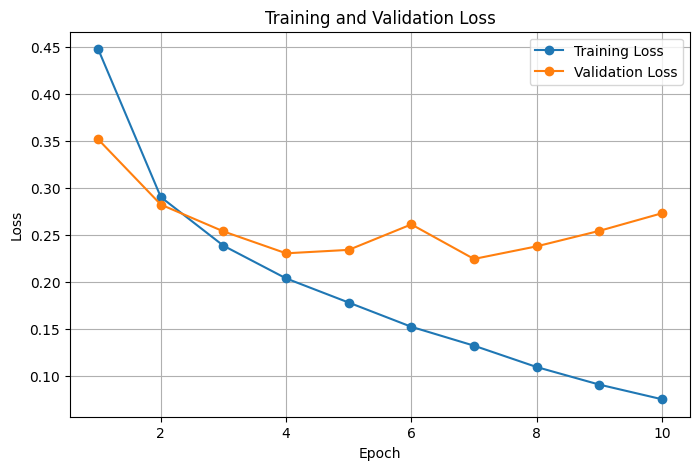

In [25]:
# Step 18 — Loss vs Epoch

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

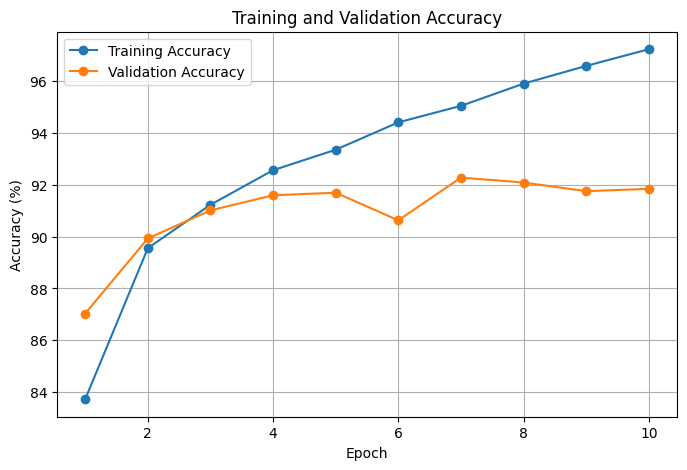

In [26]:
# Step 19 — Accuracy vs Epoch

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [27]:
# Step 20 — Test Accuracy

test_loss, test_accuracy = validate(
    model,
    test_loader,
    criterion
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.2789
Test Accuracy: 91.93%


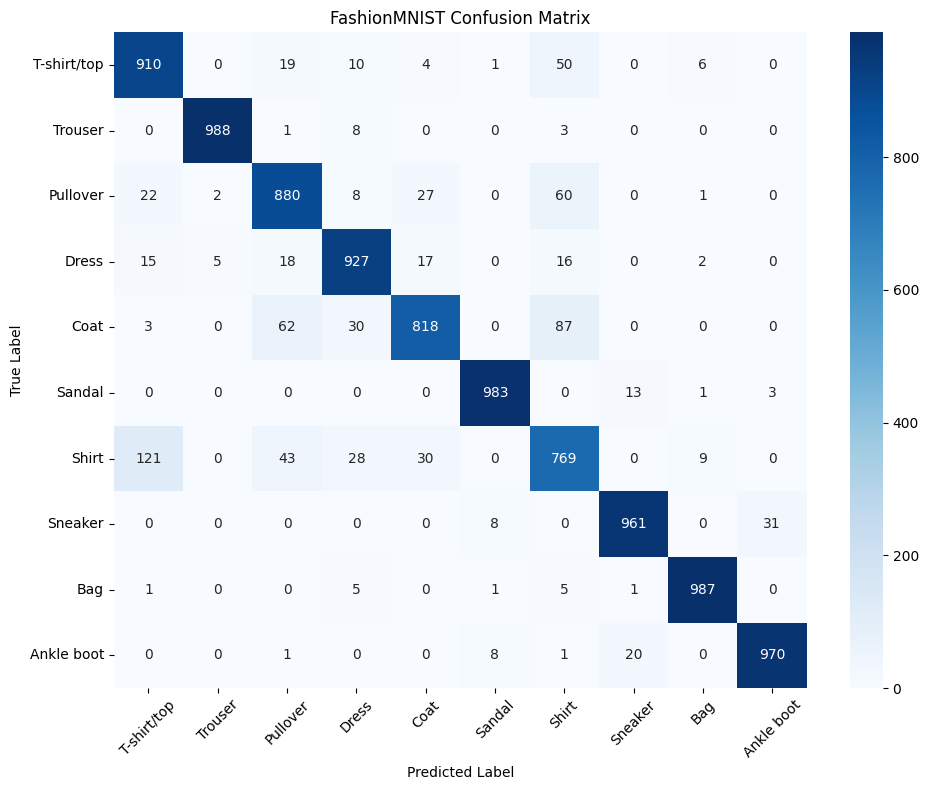

In [28]:
# Step 21 — Confusion Matrix

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("FashionMNIST Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [29]:
# Step 22 — Save Model

MODEL_DIR = os.path.join(REPO_PATH, "model")

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "FashionMNIST_CNN.pth"
)

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print("Model saved successfully:")
print(MODEL_PATH)

Model saved successfully:
/content/FashionMNIST-CNN/model/FashionMNIST_CNN.pth


In [30]:
# Step 23 — Verify Saved Model

import os

print("Model exists:", os.path.exists(MODEL_PATH))
print("Model size:", os.path.getsize(MODEL_PATH), "bytes")

Model exists: True
Model size: 1690251 bytes


In [31]:
# Step 24 — Load Saved Model

loaded_model = CNN().to(device)

loaded_model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

loaded_model.eval()

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [32]:
# Step 25 — Custom Image Transform

custom_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [33]:
# Step 26 — Custom Image List

custom_images = [
    ("tshirt.jpg", "T-shirt/top"),
    ("trouser.jpg", "Trouser"),
    ("pullover.jpg", "Pullover"),
    ("dress.jpg", "Dress"),
    ("coat.jpg", "Coat"),
    ("sandal.jpg", "Sandal"),
    ("shirt.jpg", "Shirt"),
    ("sneaker.jpg", "Sneaker"),
    ("bag.jpg", "Bag"),
    ("ankle_boot.jpg", "Ankle boot")
]

for filename, label in custom_images:
    print(filename, "->", label)

tshirt.jpg -> T-shirt/top
trouser.jpg -> Trouser
pullover.jpg -> Pullover
dress.jpg -> Dress
coat.jpg -> Coat
sandal.jpg -> Sandal
shirt.jpg -> Shirt
sneaker.jpg -> Sneaker
bag.jpg -> Bag
ankle_boot.jpg -> Ankle boot


In [34]:
# Step 27 — Prediction Function

def predict_custom_image(image_path):

    image = Image.open(image_path)

    transformed_image = custom_transform(image)

    input_tensor = transformed_image.unsqueeze(0).to(device)

    loaded_model.eval()

    with torch.no_grad():

        output = loaded_model(input_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            1
        )

    predicted_class = classes[prediction.item()]
    confidence_percentage = confidence.item() * 100

    return (
        image,
        predicted_class,
        confidence_percentage
    )

In [43]:
# Step 28 — Test One Phone Image

filename = custom_images[0][0]

image_path = os.path.join(
    CUSTOM_PATH,
    filename
)

image, predicted_class, confidence = predict_custom_image(
    image_path
)

print("Image:", filename)
print("Predicted Class:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

Image: tshirt.jpg
Predicted Class: Shirt
Confidence: 86.66%


In [36]:
# Check the actual custom image files

import os

CUSTOM_PATH = "/content/FashionMNIST-CNN/dataset"

print("Dataset exists:", os.path.exists(CUSTOM_PATH))

if os.path.exists(CUSTOM_PATH):
    print("\nFiles found:")
    for file in os.listdir(CUSTOM_PATH):
        print(file)
else:
    print("Dataset folder does not exist.")

Dataset exists: False
Dataset folder does not exist.


In [37]:
# Step 3 — Clean old repository

!rm -rf /content/FashionMNIST-CNN


In [38]:
# Step 3 — Clone your GitHub repository

!rm -rf /content/CNN_Image_Classification

!git clone https://github.com/mdparvezcse/CNN_Image_Classification.git /content/CNN_Image_Classification


Cloning into '/content/CNN_Image_Classification'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 40 (delta 3), reused 40 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 32.08 MiB | 22.51 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [39]:
# Step 4 — Check repository contents

REPO_PATH = "/content/CNN_Image_Classification"

print("Repository exists:", os.path.exists(REPO_PATH))

!find /content/CNN_Image_Classification -maxdepth 3 -type f

Repository exists: True
/content/CNN_Image_Classification/dataset/pullover.jpg
/content/CNN_Image_Classification/dataset/sandal.jpg
/content/CNN_Image_Classification/dataset/tshirt.jpg
/content/CNN_Image_Classification/dataset/shirt.jpg
/content/CNN_Image_Classification/dataset/trouser.jpg
/content/CNN_Image_Classification/dataset/bag.jpg
/content/CNN_Image_Classification/dataset/coat.jpg
/content/CNN_Image_Classification/dataset/dress.jpg
/content/CNN_Image_Classification/dataset/sneaker.jpg
/content/CNN_Image_Classification/dataset/ankle_boot.jpg
/content/CNN_Image_Classification/.git/description
/content/CNN_Image_Classification/.git/HEAD
/content/CNN_Image_Classification/.git/hooks/prepare-commit-msg.sample
/content/CNN_Image_Classification/.git/hooks/update.sample
/content/CNN_Image_Classification/.git/hooks/pre-merge-commit.sample
/content/CNN_Image_Classification/.git/hooks/pre-applypatch.sample
/content/CNN_Image_Classification/.git/hooks/pre-commit.sample
/content/CNN_Image_Cl

In [40]:
# Step 5 — Find dataset/images

import os

print("Repository folders/files:")

for item in os.listdir(REPO_PATH):
    print(item)

Repository folders/files:
dataset
.git


In [41]:
# Find all image files inside the repository

image_files = []

for root, dirs, files in os.walk(REPO_PATH):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            image_files.append(os.path.join(root, file))

print("Images found:", len(image_files))

for image in image_files:
    print(image)

Images found: 10
/content/CNN_Image_Classification/dataset/pullover.jpg
/content/CNN_Image_Classification/dataset/sandal.jpg
/content/CNN_Image_Classification/dataset/tshirt.jpg
/content/CNN_Image_Classification/dataset/shirt.jpg
/content/CNN_Image_Classification/dataset/trouser.jpg
/content/CNN_Image_Classification/dataset/bag.jpg
/content/CNN_Image_Classification/dataset/coat.jpg
/content/CNN_Image_Classification/dataset/dress.jpg
/content/CNN_Image_Classification/dataset/sneaker.jpg
/content/CNN_Image_Classification/dataset/ankle_boot.jpg


In [42]:
CUSTOM_PATH = "/content/CNN_Image_Classification/dataset"

print("Custom dataset:", CUSTOM_PATH)
print("Exists:", os.path.exists(CUSTOM_PATH))

Custom dataset: /content/CNN_Image_Classification/dataset
Exists: True


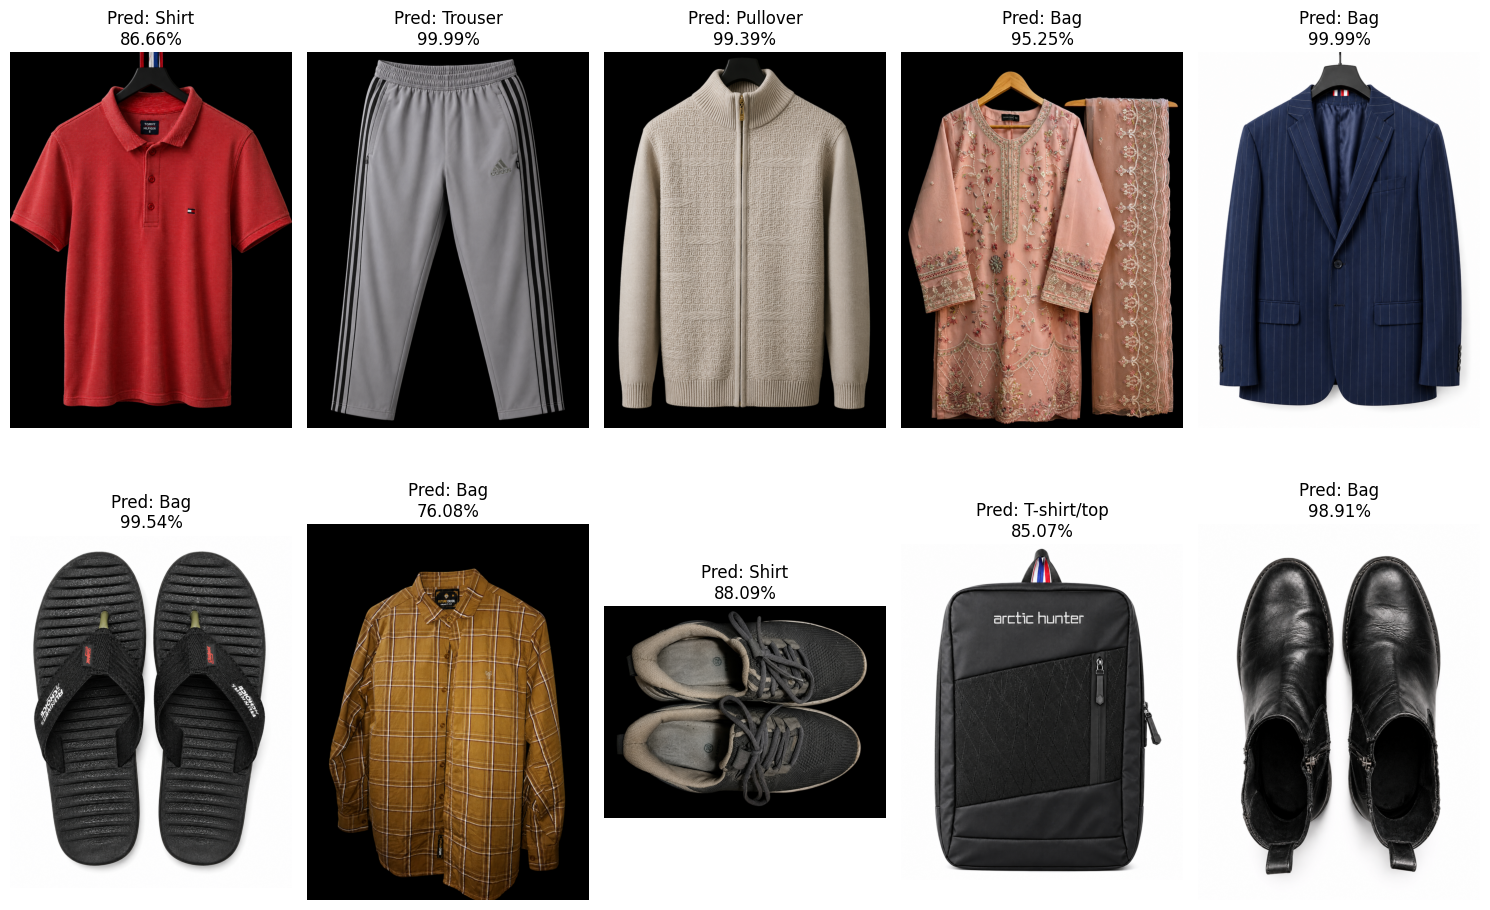

In [44]:
# Step 29 — Custom Prediction Gallery

plt.figure(figsize=(15, 10))

for i, (filename, true_class) in enumerate(custom_images):

    image_path = os.path.join(
        CUSTOM_PATH,
        filename
    )

    image, predicted_class, confidence = predict_custom_image(
        image_path
    )

    plt.subplot(2, 5, i + 1)

    plt.imshow(image)

    plt.title(
        f"Pred: {predicted_class}\n"
        f"{confidence:.2f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

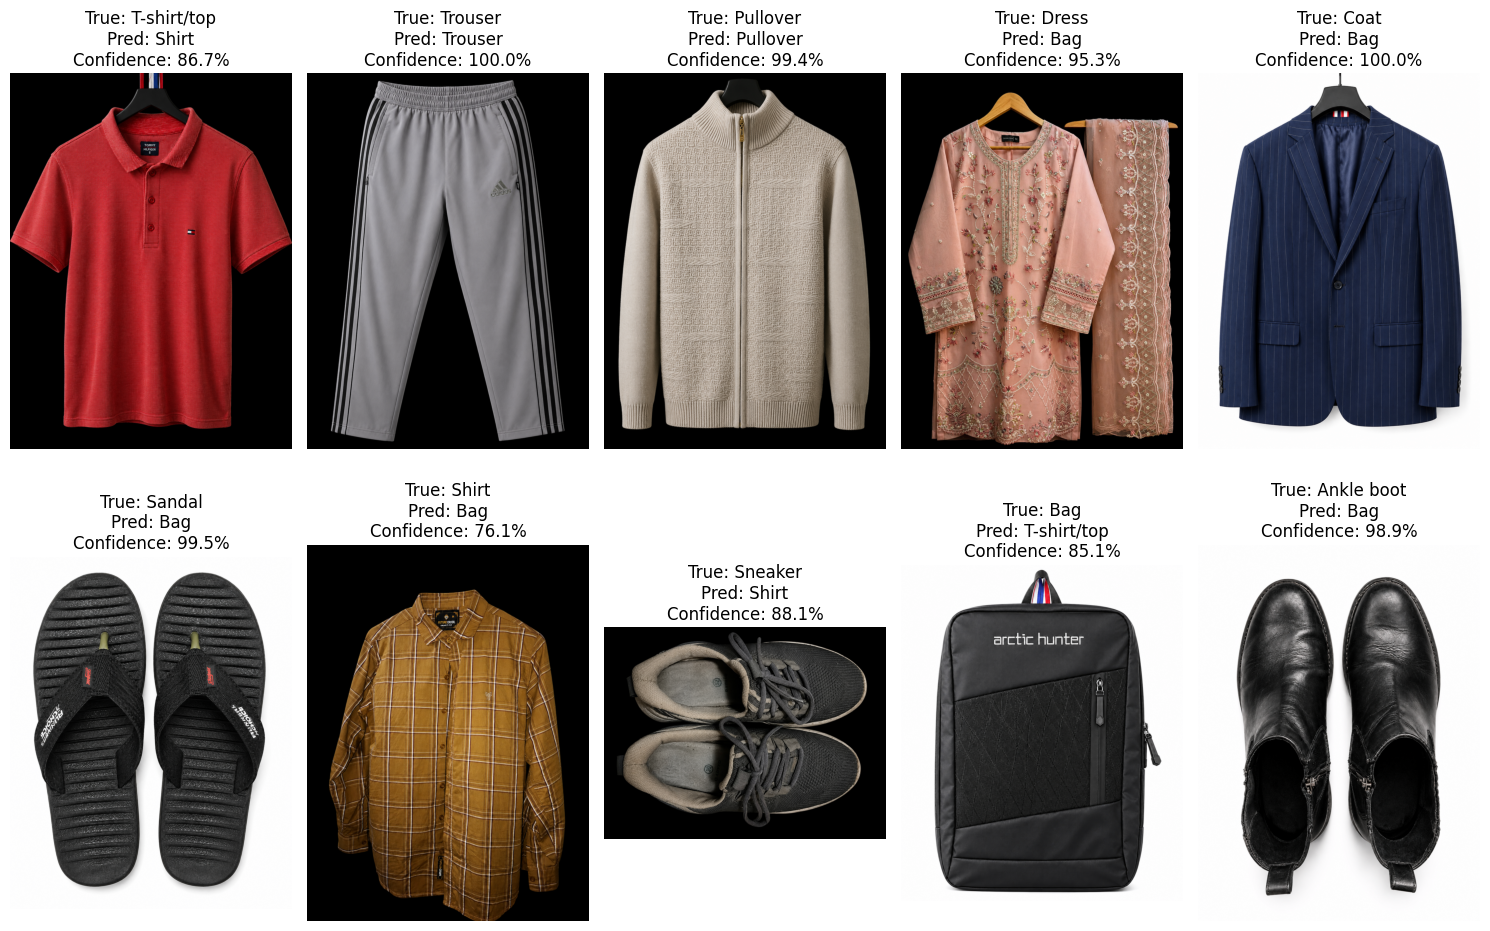

In [45]:
# Step 30 — Detailed Custom Prediction Gallery

plt.figure(figsize=(15, 10))

for i, (filename, true_class) in enumerate(custom_images):

    image_path = os.path.join(
        CUSTOM_PATH,
        filename
    )

    image, predicted_class, confidence = predict_custom_image(
        image_path
    )

    plt.subplot(2, 5, i + 1)

    plt.imshow(image)

    plt.title(
        f"True: {true_class}\n"
        f"Pred: {predicted_class}\n"
        f"Confidence: {confidence:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [46]:
# Step 31 — Find Incorrect Predictions

model.eval()

incorrect_images = []
incorrect_labels = []
incorrect_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predictions = torch.max(
            outputs,
            1
        )

        for i in range(len(labels)):

            if predictions[i].item() != labels[i].item():

                incorrect_images.append(
                    images[i].cpu()
                )

                incorrect_labels.append(
                    labels[i].item()
                )

                incorrect_predictions.append(
                    predictions[i].item()
                )

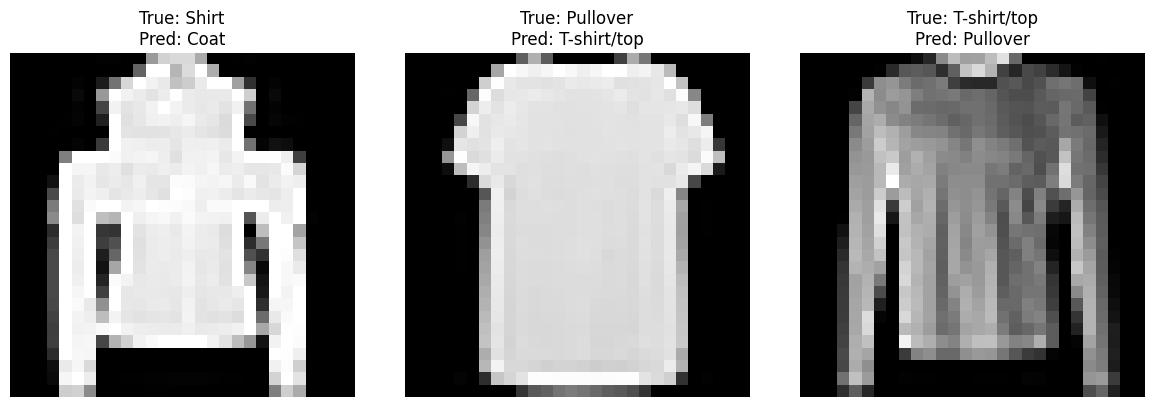

In [47]:
# Step 32 — Visual Error Analysis

num_errors = min(3, len(incorrect_images))

selected_indices = random.sample(
    range(len(incorrect_images)),
    num_errors
)

plt.figure(figsize=(12, 4))

for i, index in enumerate(selected_indices):

    image = incorrect_images[index]

    true_label = incorrect_labels[index]

    predicted_label = incorrect_predictions[index]

    # Undo normalization
    image = image.squeeze().numpy()
    image = image * 0.5 + 0.5

    plt.subplot(1, 3, i + 1)

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(
        f"True: {classes[true_label]}\n"
        f"Pred: {classes[predicted_label]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [48]:
def calculate_accuracy(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


train_accuracy = calculate_accuracy(model, train_loader)
val_accuracy = calculate_accuracy(model, val_loader)
test_accuracy = calculate_accuracy(model, test_loader)

print(f"Training Accuracy:   {train_accuracy:.2f}%")
print(f"Validation Accuracy: {val_accuracy:.2f}%")
print(f"Test Accuracy:       {test_accuracy:.2f}%")

Training Accuracy:   97.89%
Validation Accuracy: 91.85%
Test Accuracy:       91.93%


In [49]:
# Step 33 — Custom Dataset Accuracy

correct = 0
total = 0

print("Custom Image Predictions:\n")

for filename, true_class in custom_images:

    image_path = os.path.join(
        CUSTOM_PATH,
        filename
    )

    image, predicted_class, confidence = predict_custom_image(
        image_path
    )

    total += 1

    if predicted_class == true_class:
        correct += 1
        result = "Correct"
    else:
        result = "Wrong"

    print(f"Image: {filename}")
    print(f"True Class: {true_class}")
    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"Result: {result}")
    print("-" * 40)

custom_accuracy = (correct / total) * 100

print(f"\nCustom Image Accuracy: {custom_accuracy:.2f}%")
print(f"Correct Predictions: {correct}/{total}")

Custom Image Predictions:

Image: tshirt.jpg
True Class: T-shirt/top
Predicted Class: Shirt
Confidence: 86.66%
Result: Wrong
----------------------------------------
Image: trouser.jpg
True Class: Trouser
Predicted Class: Trouser
Confidence: 99.99%
Result: Correct
----------------------------------------
Image: pullover.jpg
True Class: Pullover
Predicted Class: Pullover
Confidence: 99.39%
Result: Correct
----------------------------------------
Image: dress.jpg
True Class: Dress
Predicted Class: Bag
Confidence: 95.25%
Result: Wrong
----------------------------------------
Image: coat.jpg
True Class: Coat
Predicted Class: Bag
Confidence: 99.99%
Result: Wrong
----------------------------------------
Image: sandal.jpg
True Class: Sandal
Predicted Class: Bag
Confidence: 99.54%
Result: Wrong
----------------------------------------
Image: shirt.jpg
True Class: Shirt
Predicted Class: Bag
Confidence: 76.08%
Result: Wrong
----------------------------------------
Image: sneaker.jpg
True Class: 